# Importy

In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
from functions.datasets import WLEDataSet, TransformerWLEDataSet
from functions.training import train_step, test_step
from functions.evaluation import plot_losses, eval_model, plot_residuals, print_residuals_stats, plot_predictions
from functions.models import ModelV0
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from transformers import TimeSeriesTransformerForPrediction, TimeSeriesTransformerConfig
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

# Przygotowanie danych

In [2]:
TRAIN_PROPORTION = 0.8
SEQUENCE_LENGTH = 4
BATCH_SIZE = 32

path = "../../data/B00020S_since_2014.pkl"

data = pd.read_pickle(path)
data['Date'] = pd.to_datetime(data['Date'])

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

x_scaler.fit(data.iloc[:, 2:])
y_scaler.fit(data.iloc[:, 1].values.reshape(-1, 1))

data.iloc[:, 2:] = x_scaler.transform(data.iloc[:, 2:])
data.iloc[:, 1] = y_scaler.transform(data.iloc[:, 1].values.reshape(-1, 1))

split_point = int(len(data) * TRAIN_PROPORTION)

train_data, test_data = data.iloc[:split_point], data.iloc[split_point:]

train_dataset = WLEDataSet(
    dataframe=train_data,
    sequence_length=SEQUENCE_LENGTH
)

test_dataset = WLEDataSet(
    dataframe=test_data,
    sequence_length=SEQUENCE_LENGTH
)

train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE
)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE
)

eval_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=1
)

# Model liniowy

## Trening

In [3]:
x = train_data.iloc[:, 2:]
x = sm.add_constant(x)
y = train_data.iloc[:, 1]
linear_model = sm.OLS(y, x).fit()

## Ewaluacja

mean:  0.01769
std:   0.05570
min:  -0.32245
Q1:   -0.00872
Q2:    0.02280
Q3:    0.05190
max:   0.16394


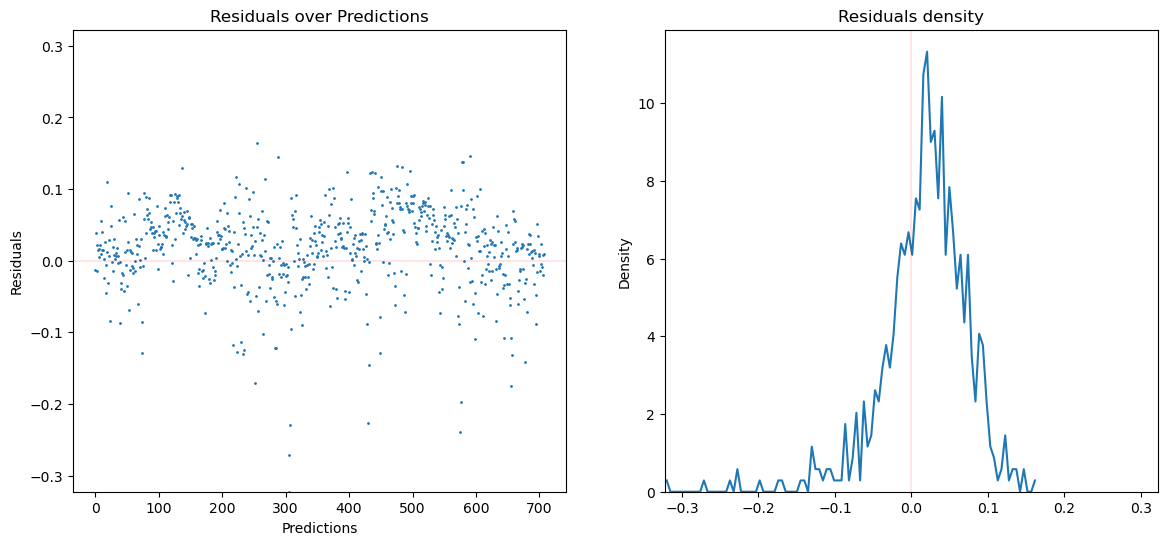

In [4]:
x_test = test_data.iloc[:, 2:]
x_test = sm.add_constant(x_test)
y_test = test_data.iloc[:, 1]
y_preds = linear_model.predict(x_test)
residuals = np.array(y_test - y_preds)

print_residuals_stats(residuals)
plot_residuals(residuals)

# Model 0 - Tradycyjny RNN

## Trening

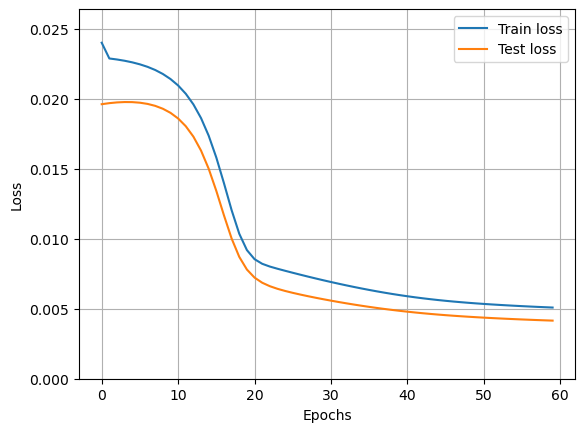

In [5]:
torch.manual_seed(9)

EPOCHS = 60
LR = 0.02

INPUT_SIZE = 9
HIDDEN_SIZE = 20
NUM_LAYERS = 5
OUTPUT_SIZE = 1

rnn_model = ModelV0(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_SIZE
).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(
    params=rnn_model.parameters(),
    lr=LR
)


train_losses = []
test_losses = []
for epoch in range(EPOCHS):
    train_loss = train_step(rnn_model, train_dataloader, loss_fn, optimizer, device)
    train_losses.append(train_loss)
    test_loss = test_step(rnn_model, test_dataloader, loss_fn, device)
    test_losses.append(test_loss)

plot_losses(train_losses, test_losses, list(range(EPOCHS)))

### Zapisanie modelu

In [6]:
path = "models/rnn_model.pth"

torch.save(rnn_model.state_dict(), path)

## Ewaluacja

### Wczytanie modelu

In [7]:
INPUT_SIZE = 9
HIDDEN_SIZE = 20
NUM_LAYERS = 5
OUTPUT_SIZE = 1

path = "models/rnn_model.pth"

rnn_model = ModelV0(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_SIZE
).to(device)

model_state = torch.load(path)
rnn_model.load_state_dict(model_state)

<All keys matched successfully>

mean: -0.01255
std:   0.06451
min:  -0.20858
Q1:   -0.05244
Q2:   -0.01474
Q3:    0.01781
max:   0.41063


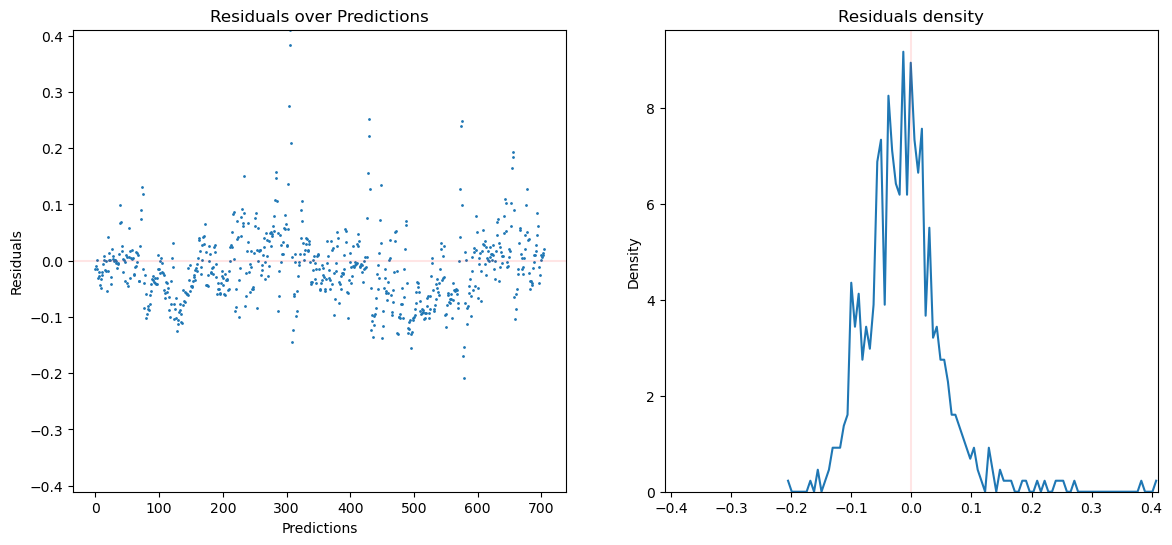

In [8]:
eval_model(rnn_model, eval_dataloader, device)

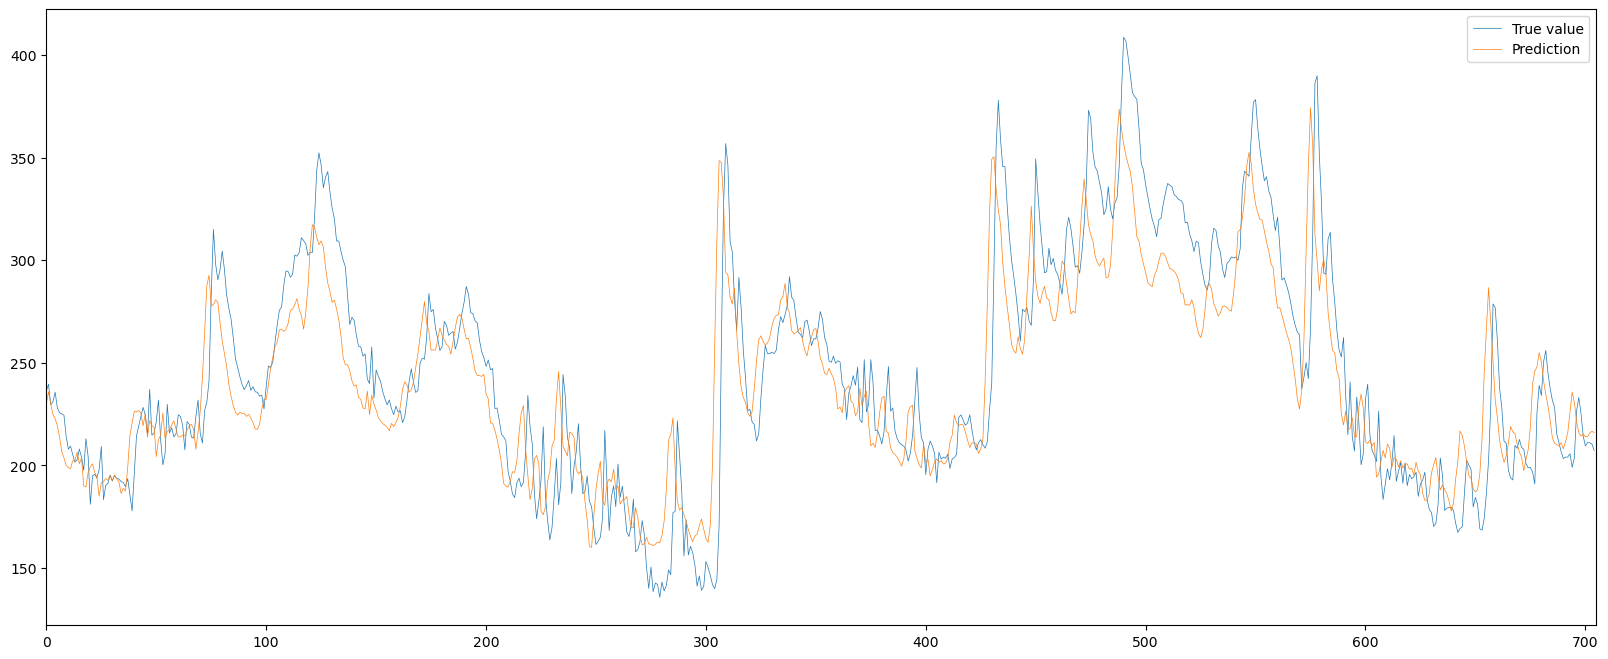

In [9]:
plot_predictions(
    model=rnn_model,
    data=test_data,
    seq_len=SEQUENCE_LENGTH,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    device=device,
)

# Model 1 - Transformer

## Przekształcenie danych

In [10]:
def collate_fn(batch):
    # Separate source and target sequences and other features if present
    past_values, future_values, past_time_features, future_time_features, past_observed_mask = zip(*batch)

    # Convert lists to tensors and pad sequences
    past_values = pad_sequence([b.clone().detach() for b in past_values], batch_first=True, padding_value=0)
    future_values = pad_sequence([b.clone().detach() for b in future_values], batch_first=True, padding_value=0)
    past_time_features = pad_sequence([b.clone().detach() for b in past_time_features], batch_first=True, padding_value=0)
    future_time_features = pad_sequence([b.clone().detach() for b in future_time_features], batch_first=True, padding_value=0)
    past_observed_mask = pad_sequence([b.clone().detach().to(torch.bool) for b in past_observed_mask], batch_first=True, padding_value=False)

    return past_values, future_values, past_time_features, future_time_features, past_observed_mask

TRAIN_PROPORTION = 0.8
SEQUENCE_LENGTH = 8
BATCH_SIZE = 32

data_transformer = data.copy()

data_transformer['Year'] = data_transformer['Date'].dt.year
data_transformer['Month'] = data_transformer['Date'].dt.month
data_transformer['Day'] = data_transformer['Date'].dt.day

data_transformer = data_transformer[['Year', 'Month', 'Day', 'GŁOGÓW', 'ŚCINAWA', 'MALCZYCE', 'BRZEG DOLNY', 'OŁAWA',
                                     'BRZEG', 'RACIBÓRZ-MIEDONIA', 'KRZYŻANOWICE', 'OLZA', 'CHAŁUPKI']]

split_point = int(len(data_transformer) * TRAIN_PROPORTION)

train_data_transformer, test_data_transformer = data_transformer.iloc[:split_point], data_transformer.iloc[split_point:]

train_dataset_transformer = TransformerWLEDataSet(
    dataframe=train_data_transformer,
    sequence_length=SEQUENCE_LENGTH
)

test_dataset_transformer = TransformerWLEDataSet(
    dataframe=test_data_transformer,
    sequence_length=SEQUENCE_LENGTH
)

train_dataloader_transformer = DataLoader(
    dataset=train_dataset_transformer,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn
)

test_dataloader_transformer = DataLoader(
    dataset=test_dataset_transformer,
    batch_size=BATCH_SIZE,
    collate_fn=collate_fn
)

eval_dataloader_transformer = DataLoader(
    dataset=test_dataset_transformer,
    batch_size=1,
    collate_fn=collate_fn
)

## Trening

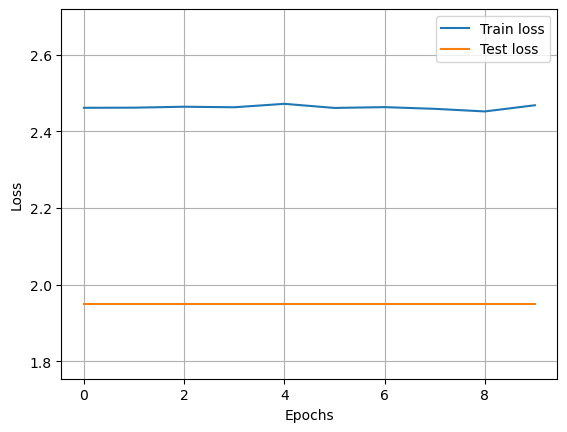

In [11]:
torch.manual_seed(9)

EPOCHS = 10
LR = 0.01

INPUT_SIZE = 10
PRED_LENGTH = 1
NUM_TIME_FEATURES = 3

NUM_ENCODER_LAYERS = 10
NUM_DECODER_LAYERS = 10
EMBED_DIM = 64
LAGS_SEQUENCE = [1, 2, 3, 4]

config = TimeSeriesTransformerConfig(
    input_size=INPUT_SIZE,
    prediction_length=OUTPUT_SIZE,
    context_length=SEQUENCE_LENGTH - max(LAGS_SEQUENCE),
    encoder_layers=NUM_ENCODER_LAYERS,
    decoder_layers=NUM_DECODER_LAYERS,
    d_model=EMBED_DIM,
    lags_sequence=LAGS_SEQUENCE,
    num_time_features=NUM_TIME_FEATURES
)

transformer_model = TimeSeriesTransformerForPrediction(config).to(device)

optimizer = torch.optim.RMSprop(
    params=transformer_model.parameters(),
    lr=LR
)

train_losses = []
test_losses = []
for epoch in range(EPOCHS):
    
    train_total_loss = 0
    transformer_model.train()
    for past_values, future_values, past_time_features, future_time_features, past_observed_mask in train_dataloader_transformer:

        past_values = past_values.to(device)
        future_values = future_values.to(device)
        past_time_features = past_time_features.to(device)
        future_time_features = future_time_features.to(device)
        past_observed_mask = past_observed_mask.to(device)

        future_values = future_values.unsqueeze(1)
        future_time_features = future_time_features.unsqueeze(1)

        outputs = transformer_model(
            past_values=past_values,
            future_values=future_values,
            past_time_features=past_time_features,
            future_time_features=future_time_features,
            past_observed_mask=past_observed_mask,
            return_dict=True
        )

        loss = outputs.loss
        loss.backward()
        train_total_loss += loss.item() * -1

    train_losses.append(train_total_loss / len(train_dataloader_transformer))

    test_total_loss = 0
    transformer_model.eval()
    with torch.inference_mode():
        for past_values, future_values, past_time_features, future_time_features, past_observed_mask in test_dataloader_transformer:

            past_values = past_values.to(device)
            future_values = future_values.to(device)
            past_time_features = past_time_features.to(device)
            future_time_features = future_time_features.to(device)
            past_observed_mask = past_observed_mask.to(device)

            future_values = future_values.unsqueeze(1)
            future_time_features = future_time_features.unsqueeze(1)

            outputs = transformer_model(
                past_values=past_values,
                future_values=future_values,
                past_time_features=past_time_features,
                future_time_features=future_time_features,
                past_observed_mask=past_observed_mask,
                return_dict=True
            )

            loss = outputs.loss
            test_total_loss += loss.item() * -1

    test_losses.append(test_total_loss / len(test_dataloader_transformer))

epochs_list = range(EPOCHS)

plt.plot(epochs_list, train_losses, label="Train loss")
plt.plot(epochs_list, test_losses, label="Test loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
max_value = max(max(train_losses), max(test_losses))
min_value = min(min(train_losses), min(test_losses))
plt.ylim(min_value * 0.9, max_value * 1.1)
plt.legend(loc="best")
plt.grid()
plt.show()

# Model 2 - LSTM

## Trening

### Zapisanie modelu

## Ewaluacja

### Wczytanie modelu